# Avaliação de Modelos de Séries Temporais em Python
## Separação temporal, Cross-Validation, Backtesting e Métricas com `sktime`


### Objetivos

Ao final deste notebook, o aluno deverá ser capaz de:

- entender por que a divisão aleatória tradicional não é apropriada para forecasting;
- utilizar bibliotecas especializadas para separar treino e teste;
- comparar **holdout temporal, expanding window e sliding/rolling window**;
- utilizar `sktime` para validação cruzada temporal e backtesting;
- comparar um **benchmark** com ARIMA/SARIMA;
- calcular **MAE, MSE, RMSE, MAPE, sMAPE e MASE** usando implementações de biblioteca;
- avaliar modelos em diferentes horizontes de previsão;
- interpretar média, mediana, dispersão e desempenho por fold;
- preservar um **teste final intocado**.

> **Princípio central:** a avaliação deve reproduzir o cenário em que o modelo será utilizado: treinar usando o passado e prever o futuro.

# 1. Por que séries temporais exigem uma validação diferente?

Em problemas convencionais de Machine Learning, podemos frequentemente embaralhar os dados antes de criar treino e teste.

Em séries temporais isso pode produzir **vazamento temporal**.

Imagine:

```text
2020  2021  2022  2023  2024  2025
 |-----|-----|-----|-----|-----|----->
```

Se o modelo é treinado com observações de 2025 para prever 2023, estamos permitindo que o modelo utilize informações que não estariam disponíveis no momento da previsão.

A divisão correta preserva a ordem:

```text
PASSADO ---------------------------------> FUTURO

|---------------- TREINO ----------------|--- TESTE ---|
```

O objetivo não é simplesmente medir o quanto o modelo se ajusta aos dados históricos.

Queremos estimar:

> **Qual será o erro quando o modelo encontrar dados futuros que ainda não conhece?**

Por isso, em forecasting, a validação precisa respeitar a dimensão temporal.

# 2. Bibliotecas especializadas

Neste notebook vamos utilizar a biblioteca:

### `sktime`

O `sktime` é um framework especializado em tarefas de séries temporais e forecasting. Ele oferece:

- `temporal_train_test_split`;
- `ExpandingWindowSplitter`;
- `SlidingWindowSplitter`;
- `ForecastingHorizon`;
- `evaluate`;
- métricas específicas de forecasting;
- wrappers e forecasters para diversos modelos.

### `scikit-learn`

Também veremos `TimeSeriesSplit`, que é útil para compreender a implementação de cross-validation temporal no ecossistema sklearn.

### `statsmodels`

Será utilizado quando quisermos trabalhar diretamente com modelos ARIMA/SARIMA.

### Instalação

Se necessário, execute a célula abaixo antes de iniciar:

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import TimeSeriesSplit

from sktime.datasets import load_airline
from sktime.split import (
    temporal_train_test_split,
    ExpandingWindowSplitter,
    SlidingWindowSplitter
)
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.arima import ARIMA

from sktime.forecasting.model_evaluation import evaluate

from sktime.performance_metrics.forecasting import (
    MeanAbsoluteError,
    MeanSquaredError,
    MeanAbsolutePercentageError,
    MeanAbsoluteScaledError,
    MeanAbsolutePercentageError,
    MeanSquaredPercentageError
)

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


# 3. Separação temporal: três estratégias principais

Vamos trabalhar com três abordagens.

## 3.1 Holdout temporal

Uma única divisão:

```text
|---------------- DESENVOLVIMENTO ----------------|--- TESTE ---|
```

É útil para uma avaliação final.

## 3.2 Expanding Window

A janela de treinamento cresce:

```text
Fold 1: |---------|--teste--|
Fold 2: |------------|--teste--|
Fold 3: |----------------|--teste--|
Fold 4: |--------------------|--teste--|
```

As observações históricas permanecem disponíveis.

## 3.3 Sliding / Rolling Window

A janela possui tamanho fixo:

```text
Fold 1: |---------|--teste--|
Fold 2:    |---------|--teste--|
Fold 3:       |---------|--teste--|
Fold 4:          |---------|--teste--|
```

É interessante quando o processo pode sofrer mudanças de regime e observações muito antigas podem perder relevância.

# 4. Métricas de forecasting

Vamos utilizar implementações de biblioteca para evitar erros de implementação.

## MAE

$$MAE = \frac{1}{n}\sum |y_t-\hat y_t|$$

Interpretação: erro absoluto médio na unidade original.

## MSE

$$MSE = \frac{1}{n}\sum(y_t-\hat y_t)^2$$

Penaliza mais fortemente erros grandes.

## RMSE

$$RMSE=\sqrt{MSE}$$

Retorna à unidade original.

## MAPE

$$MAPE=\frac{100}{n}\sum\left|\frac{y_t-\hat y_t}{y_t}\right|$$

É intuitivo, mas possui problemas com zeros e valores próximos de zero.

## sMAPE

Uma formulação comum:

$$sMAPE=\frac{100}{n}\sum
\frac{2|y_t-\hat y_t|}
{|y_t|+|\hat y_t|}$$

## MASE

O MASE compara o erro do modelo com o erro de uma previsão ingênua de referência.

Para uma série sazonal:

$$
MASE =
\frac{MAE_{forecast}}
{MAE_{naive,sazonal}}
$$

Assim:

- **MASE < 1** → melhor que o benchmark;
- **MASE = 1** → semelhante ao benchmark;
- **MASE > 1** → pior que o benchmark.

### Cuidado

A escala do MASE deve ser calculada a partir do treinamento. Isso evita utilizar informação futura na métrica.

# 5. As métricas não devem ser analisadas isoladamente

Um modelo pode ser:

- melhor em MAE;
- pior em RMSE;
- semelhante em MAPE;
- melhor em MASE.

Isso não significa necessariamente que exista um erro no cálculo.

As métricas respondem perguntas diferentes.

### Exemplo

Se grandes erros são particularmente prejudiciais:

> RMSE pode receber maior importância.

Se queremos uma interpretação direta na unidade da variável:

> MAE é muito intuitivo.

Se queremos saber se o modelo supera uma referência ingênua:

> MASE é especialmente interessante.

### Além da métrica média

No backtesting devemos observar:

- média;
- mediana;
- desvio-padrão;
- pior fold;
- desempenho ao longo do tempo;
- desempenho por horizonte.

Portanto:

> **Não escolha um modelo simplesmente porque ele apresentou o menor valor em uma única métrica e em um único fold.**

# Exemplo 1 — Flights / AirPassengers

Vamos utilizar o dataset `Airline` disponibilizado pelo próprio `sktime`.

A série possui:

- frequência mensal;
- 144 observações;
- sazonalidade anual;
- tendência;
- forte crescimento ao longo do tempo.

É um excelente exemplo para:

- Seasonal Naive;
- ARIMA/SARIMA;
- horizonte de 12 meses;
- MASE sazonal;
- expanding window;
- sliding window.

Period
1949-01    112.0
1949-02    118.0
1949-03    132.0
1949-04    129.0
1949-05    121.0
Freq: M, Name: Number of airline passengers, dtype: float64

Número de observações: 144
Índice: PeriodIndex(['1949-01', '1949-02', '1949-03', '1949-04', '1949-05', '1949-06',
             '1949-07', '1949-08', '1949-09', '1949-10',
             ...
             '1960-03', '1960-04', '1960-05', '1960-06', '1960-07', '1960-08',
             '1960-09', '1960-10', '1960-11', '1960-12'],
            dtype='period[M]', name='Period', length=144)


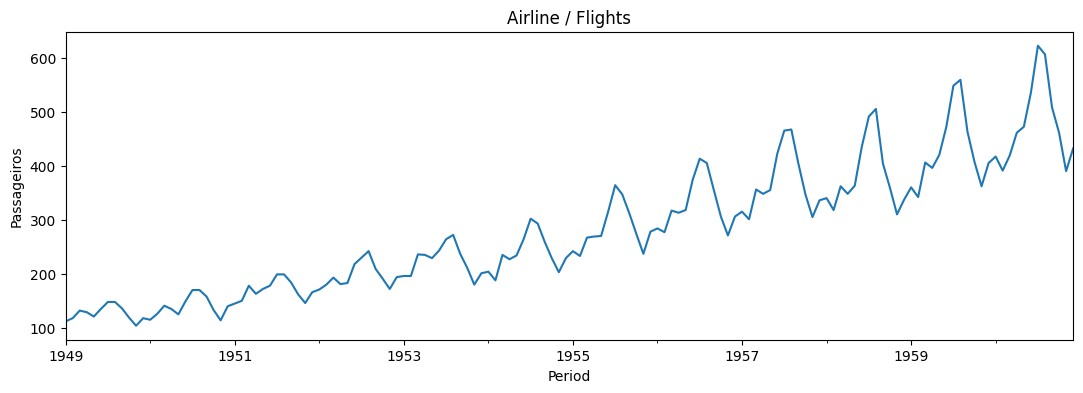

In [2]:
y_airline = load_airline()

print(y_airline.head())
print("\nNúmero de observações:", len(y_airline))
print("Índice:", y_airline.index)

y_airline.plot(figsize=(13, 4), title="Airline / Flights")
plt.ylabel("Passageiros")
plt.show()

## 6. Holdout temporal com `sktime`

Em vez de criar manualmente uma função para cortar a série, utilizamos:

```python
temporal_train_test_split()
```

Vamos reservar os últimos 24 meses para o teste.

Essa escolha deixa dois ciclos sazonais completos no teste.

Treino:
1949-01 até 1958-12

Teste:
1959-01 até 1960-12


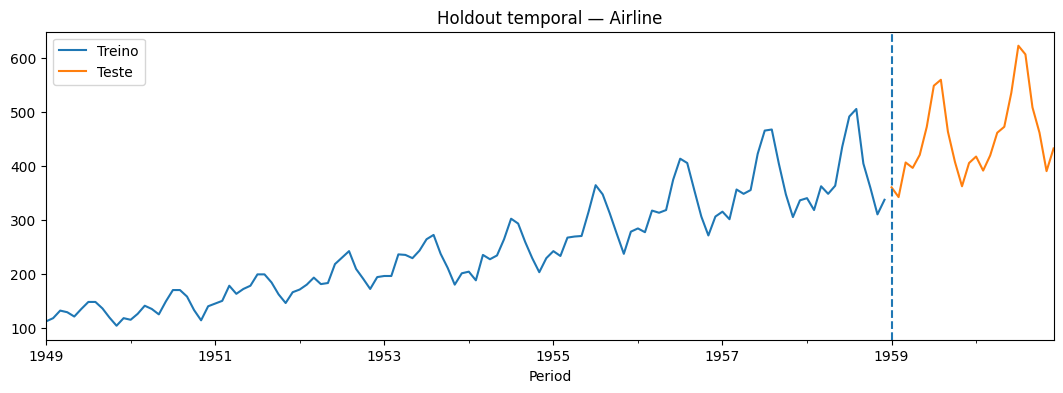

In [3]:
y_train, y_test = temporal_train_test_split(
    y_airline,
    test_size=24
)

print("Treino:")
print(y_train.index.min(), "até", y_train.index.max())

print("\nTeste:")
print(y_test.index.min(), "até", y_test.index.max())

fig, ax = plt.subplots(figsize=(13, 4))
y_train.plot(ax=ax, label="Treino")
y_test.plot(ax=ax, label="Teste")
ax.axvline(y_test.index[0], linestyle="--")
ax.set_title("Holdout temporal — Airline")
ax.legend()
plt.show()

## 6.1 Por que não usar `train_test_split`?

A função tradicional:

```python
from sklearn.model_selection import train_test_split
```

é desenhada para divisão aleatória.

Para séries temporais, queremos preservar a ordem.

No `sklearn`, existe uma alternativa específica:

```python
TimeSeriesSplit
```

Vamos apenas visualizar seu funcionamento.

In [4]:
X_demo = np.arange(len(y_airline)).reshape(-1, 1)

tscv = TimeSeriesSplit(
    n_splits=4,
    test_size=12
)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_demo), 1):
    print(
        f"Fold {fold}: "
        f"treino={len(train_idx)} observações | "
        f"teste={len(test_idx)} observações | "
        f"treino termina em índice {train_idx[-1]}"
    )

Fold 1: treino=96 observações | teste=12 observações | treino termina em índice 95
Fold 2: treino=108 observações | teste=12 observações | treino termina em índice 107
Fold 3: treino=120 observações | teste=12 observações | treino termina em índice 119
Fold 4: treino=132 observações | teste=12 observações | treino termina em índice 131


### `TimeSeriesSplit` × `sktime`

O `TimeSeriesSplit` é excelente para mostrar a ideia de cross-validation temporal no ecossistema sklearn.

Para forecasting, porém, o `sktime` fornece uma estrutura mais especializada, porque trabalha diretamente com:

- forecasting horizon;
- janelas temporais;
- forecasters;
- avaliação de forecasting.

A partir daqui, vamos utilizar principalmente `sktime`.

## 6.2 Benchmark — Seasonal Naive

O benchmark será:

$$\hat y_t=y_{t-12}$$

No `sktime`, isso pode ser especificado com:

```python
NaiveForecaster(strategy="last", sp=12)
```

O parâmetro `sp=12` representa a periodicidade sazonal.

In [5]:
fh_24 = ForecastingHorizon(
    np.arange(1, 25),
    is_relative=True
)

seasonal_naive = NaiveForecaster(
    strategy="last",
    sp=12
)

seasonal_naive.fit(y_train)

pred_naive = seasonal_naive.predict(fh=fh_24)

pred_naive.head()

1959-01    340.0
1959-02    318.0
1959-03    362.0
1959-04    348.0
1959-05    363.0
Freq: M, Name: Number of airline passengers, dtype: float64

## 6.3 ARIMA/SARIMA

Agora vamos utilizar o `ARIMA` do `sktime`.

Para uma série sazonal, podemos especificar a ordem sazonal.

Vamos utilizar:

$$SARIMA(1,1,1)(1,1,1)_{12}$$

O objetivo não é fazer seleção automática de hiperparâmetros nesta aula. O foco é a **avaliação**.

In [6]:
sarima = ARIMA(
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    suppress_warnings=True
)

sarima.fit(y_train)

pred_sarima = sarima.predict(fh=fh_24)

pred_sarima.head()

C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


1959-01    342.247463
1959-02    320.376555
1959-03    366.168214
1959-04    353.209843
1959-05    367.449803
Freq: M, Name: Number of airline passengers, dtype: float64

## 6.4 Métricas usando `sktime`

Vamos criar os objetos de métricas.

O ponto importante é que não precisamos implementar MAE, MSE, MAPE ou MASE manualmente.

Para MASE, informaremos a periodicidade sazonal.

In [7]:
mae_metric = MeanAbsoluteError()
mse_metric = MeanSquaredError()
mape_metric = MeanAbsolutePercentageError()

# MASE com escala sazonal de 12 períodos
mase_metric = MeanAbsoluteScaledError(
    sp=12
)

def evaluate_predictions_sktime(y_train, y_test, y_pred, mase_sp=1):
    metrics = {
        "MAE": MeanAbsoluteError()(y_test, y_pred),
        "MSE": MeanSquaredError()(y_test, y_pred),
        "RMSE": np.sqrt(MeanSquaredError()(y_test, y_pred)),
        "MAPE": MeanAbsolutePercentageError()(y_test, y_pred),
        "sMAPE": 100 * np.mean(
            2 * np.abs(np.asarray(y_test) - np.asarray(y_pred))
            / (
                np.abs(np.asarray(y_test))
                + np.abs(np.asarray(y_pred))
            )
        ),
        "MASE": MeanAbsoluteScaledError(
            sp=mase_sp
        )(y_test, y_pred, y_train=y_train)
    }
    return pd.Series(metrics)

metrics_naive = evaluate_predictions_sktime(
    y_train, y_test, pred_naive, mase_sp=12
)

metrics_sarima = evaluate_predictions_sktime(
    y_train, y_test, pred_sarima, mase_sp=12
)

holdout_airline = pd.DataFrame({
    "Seasonal Naive": metrics_naive,
    "SARIMA": metrics_sarima
})

holdout_airline

,Seasonal Naive,SARIMA
MAE,71.250000,68.038836
MSE,5928.166667,5471.479401
RMSE,76.994589,73.969449
MAPE,0.155234,0.147937
sMAPE,17.012625,16.155497
MASE,2.493519,2.381139


### Observação sobre sMAPE

O `sktime` possui várias métricas de forecasting, mas diferentes bibliotecas podem adotar convenções ligeiramente diferentes para métricas percentuais.

Neste notebook, mantemos o cálculo do **sMAPE** explicitamente visível para que a fórmula ensinada em aula fique transparente.

Isso não significa implementar manualmente o processo de validação: o split, o backtesting e as demais métricas continuam sendo realizados pelas bibliotecas especializadas.

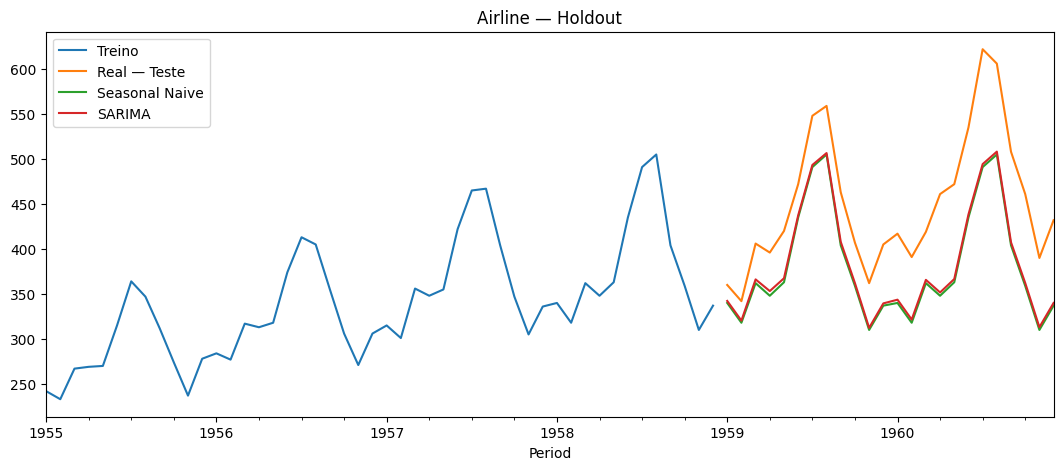

In [8]:
plt.figure(figsize=(13, 5))
y_train.iloc[-48:].plot(label="Treino")
y_test.plot(label="Real — Teste")
pred_naive.plot(label="Seasonal Naive")
pred_sarima.plot(label="SARIMA")
plt.title("Airline — Holdout")
plt.legend()
plt.show()

# 7. Expanding Window com `sktime`

Agora entra a principal estratégia de backtesting.

Vamos utilizar:

```python
ExpandingWindowSplitter
```

Com:

- janela inicial de 72 meses;
- horizonte de 12 meses;
- avanço de 12 meses.

Conceitualmente:

```text
Fold 1: |------72------|--12--|
Fold 2: |---------84---------|--12--|
Fold 3: |------------96------------|--12--|
...
```

A vantagem é avaliar o modelo em vários períodos históricos.

In [9]:
cv_expanding = ExpandingWindowSplitter(
    initial_window=72,
    step_length=12,
    fh=np.arange(1, 13)
)

for fold, (train_idx, test_idx) in enumerate(
    cv_expanding.split(y_airline), 1
):
    print(
        f"Fold {fold}: "
        f"treino={len(train_idx)} | "
        f"teste={len(test_idx)}"
    )

Fold 1: treino=72 | teste=12
Fold 2: treino=84 | teste=12
Fold 3: treino=96 | teste=12
Fold 4: treino=108 | teste=12
Fold 5: treino=120 | teste=12
Fold 6: treino=132 | teste=12


## 7.1 Backtesting com `evaluate()`

A função `evaluate()` automatiza o processo:

1. separa treino e teste em cada fold;
2. ajusta o forecaster;
3. produz as previsões;
4. calcula as métricas;
5. repete o processo nos folds.

Esse é exatamente o conceito de **rolling-origin evaluation / backtesting**.

In [10]:
# Métricas do sktime para avaliação de forecasting

metrics_airline = [
    MeanAbsoluteError(),
    MeanSquaredError(),
    MeanAbsolutePercentageError(),
    MeanAbsoluteScaledError(sp=12)
]

eval_naive_airline = evaluate(
    forecaster=NaiveForecaster(
        strategy="last",
        sp=12
    ),
    y=y_airline,
    cv=cv_expanding,
    scoring=metrics_airline,
    return_data=True
)

eval_naive_airline.head()

,test_MeanAbsoluteError,test_MeanSquaredError,test_MeanAbsolutePercentageError,test_MeanAbsoluteScaledError,fit_time,pred_time,len_train_window,cutoff,y_train,y_test,y_pred
0,45.083333,2108.750000,0.158429,1.958726,0.005041,0.025611,72,1954-12,Period 1949-01 112.0 1949-02 118.0 1949-...,Period 1955-01 242.0 1955-02 233.0 1955-...,1955-01 204.0 1955-02 188.0 1955-03 2...
1,44.250000,2041.583333,0.134854,1.657648,0.004160,0.023243,84,1955-12,Period 1949-01 112.0 1949-02 118.0 1949-...,Period 1956-01 284.0 1956-02 277.0 1956-...,1956-01 242.0 1956-02 233.0 1956-03 2...
2,40.166667,1720.166667,0.107586,1.375459,0.005048,0.023630,96,1956-12,Period 1949-01 112.0 1949-02 118.0 1949-...,Period 1957-01 315.0 1957-02 301.0 1957-...,1957-01 284.0 1957-02 277.0 1957-03 3...
3,12.583333,289.416667,0.031351,0.411584,0.004433,0.023515,108,1957-12,Period 1949-01 112.0 1949-02 118.0 1949-...,Period 1958-01 340.0 1958-02 318.0 1958-...,1958-01 315.0 1958-02 301.0 1958-03 3...
4,47.333333,2426.000000,0.110579,1.656513,0.004764,0.022420,120,1958-12,Period 1949-01 112.0 1949-02 118.0 1949-...,Period 1959-01 360.0 1959-02 342.0 1959-...,1959-01 340.0 1959-02 318.0 1959-03 3...


### Interpretação do resultado

Cada linha representa um fold.

Temos uma avaliação muito mais rica do que simplesmente:

```text
RMSE = 20
```

Agora podemos investigar:

- se o modelo é consistente;
- em quais períodos erra mais;
- se o erro aumenta com o horizonte;
- se o modelo supera o benchmark sistematicamente.

In [11]:
eval_naive_airline.columns.tolist()

['test_MeanAbsoluteError',
 'test_MeanSquaredError',
 'test_MeanAbsolutePercentageError',
 'test_MeanAbsoluteScaledError',
 'fit_time',
 'pred_time',
 'len_train_window',
 'cutoff',
 'y_train',
 'y_test',
 'y_pred']

## 7.2 SARIMA no backtesting

O mesmo protocolo será aplicado ao SARIMA.

Observe um princípio fundamental:

> **A validação é independente do modelo.**

Podemos substituir o Naive por SARIMA, ETS, Prophet ou outro forecaster sem alterar a lógica da separação temporal.

In [12]:
eval_sarima_airline = evaluate(
    forecaster=ARIMA(
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        suppress_warnings=True
    ),
    y=y_airline,
    cv=cv_expanding,
    scoring=metrics_airline,
    return_data=True
)

eval_sarima_airline.head()

C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finit

,test_MeanAbsoluteError,test_MeanSquaredError,test_MeanAbsolutePercentageError,test_MeanAbsoluteScaledError,fit_time,pred_time,len_train_window,cutoff,y_train,y_test,y_pred
0,18.093926,480.048723,0.060251,0.786123,0.297044,0.010192,72,1954-12,Period 1949-01 112.0 1949-02 118.0 1949-...,Period 1955-01 242.0 1955-02 233.0 1955-...,1955-01 231.380502 1955-02 221.413512 19...
1,8.355760,126.023136,0.025951,0.313015,0.242554,0.010908,84,1955-12,Period 1949-01 112.0 1949-02 118.0 1949-...,Period 1956-01 284.0 1956-02 277.0 1956-...,1956-01 285.587098 1956-02 277.688327 19...
2,10.511860,188.967523,0.026081,0.359966,0.350166,0.009905,96,1956-12,Period 1949-01 112.0 1949-02 118.0 1949-...,Period 1957-01 315.0 1957-02 301.0 1957-...,1957-01 314.976665 1957-02 307.766349 19...
3,19.408294,465.685366,0.053864,0.634820,0.279990,0.009356,108,1957-12,Period 1949-01 112.0 1949-02 118.0 1949-...,Period 1958-01 340.0 1958-02 318.0 1958-...,1958-01 345.255131 1958-02 332.050818 19...
4,44.291601,2142.513328,0.103263,1.550063,0.366886,0.009818,120,1958-12,Period 1949-01 112.0 1949-02 118.0 1949-...,Period 1959-01 360.0 1959-02 342.0 1959-...,1959-01 342.247463 1959-02 320.376555 19...


# 8. Sliding / Rolling Window

Agora usamos:

```python
SlidingWindowSplitter
```

A janela de treinamento possui tamanho fixo.

Exemplo:

```text
Fold 1: |--------72--------|--12--|
Fold 2:    |--------72--------|--12--|
Fold 3:       |--------72--------|--12--|
```

Essa abordagem pode ser útil quando o processo apresenta mudanças estruturais ou quando dados muito antigos são menos representativos.

In [13]:
cv_sliding = SlidingWindowSplitter(
    window_length=72,
    step_length=12,
    fh=np.arange(1, 13)
)

for fold, (train_idx, test_idx) in enumerate(
    cv_sliding.split(y_airline), 1
):
    print(
        f"Fold {fold}: "
        f"treino={len(train_idx)} | "
        f"teste={len(test_idx)}"
    )

Fold 1: treino=72 | teste=12
Fold 2: treino=72 | teste=12
Fold 3: treino=72 | teste=12
Fold 4: treino=72 | teste=12
Fold 5: treino=72 | teste=12
Fold 6: treino=72 | teste=12


In [14]:
eval_naive_sliding = evaluate(
    forecaster=NaiveForecaster(
        strategy="last",
        sp=12
    ),
    y=y_airline,
    cv=cv_sliding,
    scoring=metrics_airline,
    return_data=True
)

eval_sarima_sliding = evaluate(
    forecaster=ARIMA(
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        suppress_warnings=True
    ),
    y=y_airline,
    cv=cv_sliding,
    scoring=metrics_airline,
    return_data=True
)

display(eval_naive_sliding.head())
display(eval_sarima_sliding.head())

C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finit

,test_MeanAbsoluteError,test_MeanSquaredError,test_MeanAbsolutePercentageError,test_MeanAbsoluteScaledError,fit_time,pred_time,len_train_window,cutoff,y_train,y_test,y_pred
0,45.083333,2108.750000,0.158429,1.958726,0.004640,0.024812,72,1954-12,Period 1949-01 112.0 1949-02 118.0 1949-...,Period 1955-01 242.0 1955-02 233.0 1955-...,1955-01 204.0 1955-02 188.0 1955-03 2...
1,44.250000,2041.583333,0.134854,1.503398,0.004880,0.022643,72,1955-12,Period 1950-01 115.0 1950-02 126.0 1950-...,Period 1956-01 284.0 1956-02 277.0 1956-...,1956-01 242.0 1956-02 233.0 1956-03 2...
2,40.166667,1720.166667,0.107586,1.248058,0.004475,0.022219,72,1956-12,Period 1951-01 145.0 1951-02 150.0 1951-...,Period 1957-01 315.0 1957-02 301.0 1957-...,1957-01 284.0 1957-02 277.0 1957-03 3...
3,12.583333,289.416667,0.031351,0.361071,0.004118,0.021967,72,1957-12,Period 1952-01 171.0 1952-02 180.0 1952-...,Period 1958-01 340.0 1958-02 318.0 1958-...,1958-01 315.0 1958-02 301.0 1958-03 3...
4,47.333333,2426.000000,0.110579,1.490031,0.004415,0.026263,72,1958-12,Period 1953-01 196.0 1953-02 196.0 1953-...,Period 1959-01 360.0 1959-02 342.0 1959-...,1959-01 340.0 1959-02 318.0 1959-03 3...


,test_MeanAbsoluteError,test_MeanSquaredError,test_MeanAbsolutePercentageError,test_MeanAbsoluteScaledError,fit_time,pred_time,len_train_window,cutoff,y_train,y_test,y_pred
0,18.093926,480.048723,0.060251,0.786123,0.273605,0.010396,72,1954-12,Period 1949-01 112.0 1949-02 118.0 1949-...,Period 1955-01 242.0 1955-02 233.0 1955-...,1955-01 231.380502 1955-02 221.413512 19...
1,7.877617,105.857094,0.024046,0.267643,0.298634,0.010223,72,1955-12,Period 1950-01 115.0 1950-02 126.0 1950-...,Period 1956-01 284.0 1956-02 277.0 1956-...,1956-01 285.230685 1956-02 277.738197 19...
2,11.667266,229.528379,0.028866,0.362525,0.269067,0.009262,72,1956-12,Period 1951-01 145.0 1951-02 150.0 1951-...,Period 1957-01 315.0 1957-02 301.0 1957-...,1957-01 313.933804 1957-02 306.362827 19...
3,29.386427,1034.118630,0.081001,0.843226,1.400830,0.009895,72,1957-12,Period 1952-01 171.0 1952-02 180.0 1952-...,Period 1958-01 340.0 1958-02 318.0 1958-...,1958-01 348.288519 1958-02 336.941576 19...
4,50.383644,2778.258659,0.119057,1.586054,0.151884,0.010137,72,1958-12,Period 1953-01 196.0 1953-02 196.0 1953-...,Period 1959-01 360.0 1959-02 342.0 1959-...,1959-01 340.330585 1959-02 314.091976 19...


# Exemplo 2 — Sunspots

Agora utilizaremos a série anual de manchas solares disponível no `statsmodels`.

Este exemplo é importante porque:

- não possui periodicidade mensal;
- permite utilizar um benchmark Naive;
- utiliza ARIMA em vez de SARIMA;
- demonstra que o mesmo pipeline funciona sem sazonalidade explícita.

#### PASSO 1: Carregar os Dados e Configurar o Eixo do Tempo

In [15]:
sun = sm.datasets.sunspots.load_pandas().data.copy()

# A MÁGICA ACONTECE AQUI: Em vez de data exata, usamos "Período" anual (freq="Y")
sun.index = pd.PeriodIndex(sun["YEAR"].astype(int), freq="Y")
y_sun = sun["SUNACTIVITY"].astype(float)

print("1. Dados carregados. O Índice agora é do tipo Período (Anual).")

1. Dados carregados. O Índice agora é do tipo Período (Anual).


#### PASSO 2: Dividir em Treino e Teste

In [16]:
# Vamos separar os últimos 20 anos para testar (validar) se o modelo acerta
y_sun_train, y_sun_test = temporal_train_test_split(y_sun, test_size=20)
print(f"2. Dados divididos: {len(y_sun_train)} anos para treino, {len(y_sun_test)} anos para teste.")


2. Dados divididos: 289 anos para treino, 20 anos para teste.


#### PASSO 3: Criar o Horizonte de Previsão e Treinar o Modelo

In [17]:
# Dizemos ao modelo: "Você vai prever exatamente os anos que estão no meu grupo de teste"
fh_sun = ForecastingHorizon(y_sun_test.index, is_relative=False)

# Instanciamos o modelo ARIMA com as ordens que você definiu (2, 1, 2)
arima_sun = ARIMA(order=(2, 1, 2), suppress_warnings=True)

# Treinamos (ajustamos) o modelo com os dados de treino
arima_sun.fit(y_sun_train)
print("3. Modelo ARIMA treinado com sucesso!")

C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


3. Modelo ARIMA treinado com sucesso!


#### PASSO 4: Fazer as Previsões

In [18]:
# Pedimos para o modelo prever o futuro com base no horizonte (fh_sun)
pred_arima_sun = arima_sun.predict(fh_sun)

print("\n4. Previsões realizadas! Aqui estão os primeiros resultados:")
print(pred_arima_sun.head())


4. Previsões realizadas! Aqui estão os primeiros resultados:
YEAR
1989    141.080053
1990    163.099930
1991    160.275746
1992    135.190115
1993     97.599457
Freq: Y-DEC, Name: SUNACTIVITY, dtype: float64


C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [19]:
def evaluate_predictions_sktime(y_train, y_test, y_pred, mase_sp=1):
    """
    Função para avaliar as previsões de um modelo de Séries Temporais.
    Ela calcula os erros e retorna uma Série do Pandas com os resultados.
    """
    # Instanciando (ligando) as calculadoras de erro
    calc_mae = MeanAbsoluteError()
    calc_mse = MeanSquaredError()
    calc_mape = MeanAbsolutePercentageError()
    calc_mase = MeanAbsoluteScaledError()
    
    # Calculando cada erro comparando a Realidade (y_test) com a Previsão (y_pred)
    mae = calc_mae(y_test, y_pred)
    mse = calc_mse(y_test, y_pred)
    mape = calc_mape(y_test, y_pred)
    # O MASE precisa do y_train e da sazonalidade (sp) para calcular o erro em escala
    mase = calc_mase(y_test, y_pred, y_train=y_train, sp=mase_sp)
    
    # Retornando as notas agrupadas para formar a coluna da nossa tabela final
    return pd.Series({
        "MAE": mae,
        "MSE": mse,
        "MAPE": mape,
        "MASE": mase
    })


#### Treino , Teste e Previsão

In [20]:

# Separando 30 anos para teste
y_sun_train, y_sun_test = temporal_train_test_split(
    y_sun,
    test_size=30
)

# Criando o horizonte de previsão de 1 a 30 passos à frente (relativo)
fh_sun = ForecastingHorizon(
    np.arange(1, 31),
    is_relative=True
)

# Treinando e prevendo com o modelo Naive (Ingênuo - repete o último valor)
naive_sun = NaiveForecaster(strategy="last", sp=11)
naive_sun.fit(y_sun_train)
pred_naive_sun = naive_sun.predict(fh_sun)

# Treinando e prevendo com o modelo ARIMA
arima_sun = ARIMA(
    order=(2, 1, 2),
    suppress_warnings=True
)
arima_sun.fit(y_sun_train)
pred_arima_sun = arima_sun.predict(fh_sun)

# Construindo a tabela comparativa usando a nossa função recém-criada
sun_holdout = pd.DataFrame({
    "Naive": evaluate_predictions_sktime(
        y_sun_train,
        y_sun_test,
        pred_naive_sun,
        mase_sp=1
    ),
    "ARIMA": evaluate_predictions_sktime(
        y_sun_train,
        y_sun_test,
        pred_arima_sun,
        mase_sp=1
    )
})

# Exibindo a tabela final
print("Tabela Comparativa de Erros (Quanto MENOR, melhor!):")
display(sun_holdout) 

C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Tabela Comparativa de Erros (Quanto MENOR, melhor!):


,Naive,ARIMA
MAE,29.250000,24.780075
MSE,1254.843000,815.558464
MAPE,0.826262,1.371206
MASE,1.668513,1.413535


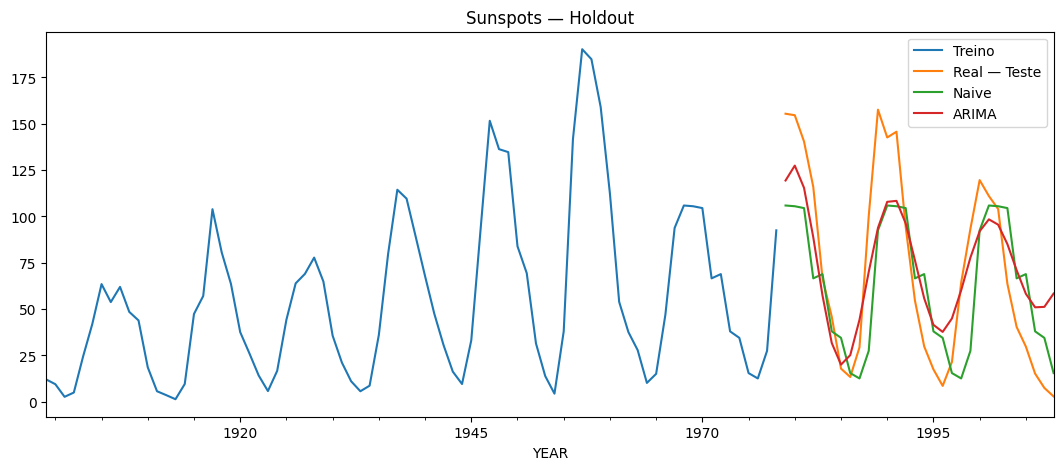

In [21]:
plt.figure(figsize=(13,5))
y_sun_train.iloc[-80:].plot(label="Treino")
y_sun_test.plot(label="Real — Teste")
pred_naive_sun.plot(label="Naive")
pred_arima_sun.plot(label="ARIMA")
plt.title("Sunspots — Holdout")
plt.legend()
plt.show()

## 9.1 Expanding e Sliding para Sunspots

Vamos comparar as duas estratégias usando o mesmo horizonte de 10 anos.

```text
Expanding:
histórico utilizado aumenta.

Sliding:
somente uma janela recente permanece no treinamento.


#### 1. CONFIGURAÇÃO DAS JANELAS DE VALIDAÇÃO CRUZADA

In [22]:

# Janela em Expansão: O treino cresce a cada passo (como uma bola de neve)
cv_sun_expanding = ExpandingWindowSplitter(
    initial_window=180,
    step_length=10,
    fh=np.arange(1, 11)
)

#### 2. DEFINIÇÃO DAS MÉTRICAS DE AVALIAÇÃO

In [23]:
sun_metrics = [
    MeanAbsoluteError(),
    MeanSquaredError(),
    MeanAbsolutePercentageError(),
    MeanAbsoluteScaledError(sp=1) 
]


#### 3. AVALIAÇÃO COM JANELA EM EXPANSÃO (EXPANDING)

In [24]:
# Correção: Adicionamos "forecaster=" e "y=" para o Python não se confundir
sun_exp_naive = evaluate(
    forecaster=NaiveForecaster(strategy="last"), 
    y=y_sun,
    cv=cv_sun_expanding,
    scoring=sun_metrics,
    return_data=True
)

sun_exp_arima = evaluate(
    forecaster=ARIMA(order=(2,1,2), suppress_warnings=True),
    y=y_sun,
    cv=cv_sun_expanding,
    scoring=sun_metrics,
    return_data=True
)


C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finit

#### 4. AVALIAÇÃO COM JANELA DESLIZANTE (SLIDING / ROLLING)

In [26]:
cv_sun_sliding = SlidingWindowSplitter(
    window_length=180,
    step_length=10,
    fh=np.arange(1, 11)
)

sun_roll_naive = evaluate(
    forecaster=NaiveForecaster(strategy="last", sp=11),
    y=y_sun,
    cv=cv_sun_sliding,
    scoring=sun_metrics,
    return_data=True
)

sun_roll_arima = evaluate(
    forecaster=ARIMA(order=(2,1,2), suppress_warnings=True),
    y=y_sun,
    cv=cv_sun_sliding,
    scoring=sun_metrics,
    return_data=True
)

C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finit

#### 5. EXIBINDO OS RESULTADOS

In [27]:
print("--- Validação Cruzada: Expanding Window (Janela em Expansão) ---")
print("Modelo: Naive")
display(sun_exp_naive.head())

print("\nModelo: ARIMA")
display(sun_exp_arima.head())

--- Validação Cruzada: Expanding Window (Janela em Expansão) ---
Modelo: Naive


,test_MeanAbsoluteError,test_MeanSquaredError,test_MeanAbsolutePercentageError,test_MeanAbsoluteScaledError,fit_time,pred_time,len_train_window,cutoff,y_train,y_test,y_pred
0,31.73,1510.575,0.677065,1.912218,0.004961,0.013463,180,1879,YEAR 1700 5.0 1701 11.0 1702 16.0 17...,YEAR 1880 32.3 1881 54.3 1882 59.7 18...,1880 6.0 1881 6.0 1882 6.0 1883 6....
1,38.66,2209.370,0.744838,2.368243,0.004737,0.014232,190,1889,YEAR 1700 5.0 1701 11.0 1702 16.0 17...,YEAR 1890 7.1 1891 35.6 1892 73.0 18...,1890 6.3 1891 6.3 1892 6.3 1893 6....
2,27.25,1039.789,1.025544,1.674670,0.004282,0.012063,200,1899,YEAR 1700 5.0 1701 11.0 1702 16.0 17...,YEAR 1900 9.5 1901 2.7 1902 5.0 19...,1900 12.1 1901 12.1 1902 12.1 1903 ...
3,31.37,1222.763,5.483405,1.960449,0.005548,0.010277,210,1909,YEAR 1700 5.0 1701 11.0 1702 16.0 17...,YEAR 1910 18.6 1911 5.7 1912 3.6...,1910 43.9 1911 43.9 1912 43.9 1913 ...
4,25.81,1066.813,1.910222,1.601425,0.004227,0.010203,220,1919,YEAR 1700 5.0 1701 11.0 1702 16.0...,YEAR 1920 37.6 1921 26.1 1922 14.2 19...,1920 63.6 1921 63.6 1922 63.6 1923 ...



Modelo: ARIMA


,test_MeanAbsoluteError,test_MeanSquaredError,test_MeanAbsolutePercentageError,test_MeanAbsoluteScaledError,fit_time,pred_time,len_train_window,cutoff,y_train,y_test,y_pred
0,8.613996,101.988943,0.697237,0.519125,1.329773,0.008429,180,1879,YEAR 1700 5.0 1701 11.0 1702 16.0 17...,YEAR 1880 32.3 1881 54.3 1882 59.7 18...,1880 26.057591 1881 48.050306 1882 64...
1,13.172825,281.010523,0.381995,0.806944,1.546165,0.008028,190,1889,YEAR 1700 5.0 1701 11.0 1702 16.0 17...,YEAR 1890 7.1 1891 35.6 1892 73.0 18...,1890 17.376945 1891 32.397239 1892 45...
2,17.774456,445.223512,2.090575,1.092343,0.619369,0.008099,200,1899,YEAR 1700 5.0 1701 11.0 1702 16.0 17...,YEAR 1900 9.5 1901 2.7 1902 5.0 19...,1900 16.694317 1901 28.748300 1902 43...
3,22.617024,669.604874,3.178284,1.413437,1.557403,0.009988,210,1909,YEAR 1700 5.0 1701 11.0 1702 16.0 17...,YEAR 1910 18.6 1911 5.7 1912 3.6...,1910 33.533596 1911 26.083850 1912 23...
4,5.128827,42.142902,0.162159,0.318227,0.120885,0.008231,220,1919,YEAR 1700 5.0 1701 11.0 1702 16.0...,YEAR 1920 37.6 1921 26.1 1922 14.2 19...,1920 38.940236 1921 17.197915 1922 5...


In [ ]:
#### PASSO 1: OTIMIZAÇÃO DA TABELA (Calculando a média dos erros)

In [28]:

resumo_erros = {
    "Modelo e Estratégia": [
        "Naive (Expanding)", 
        "ARIMA (Expanding)", 
        "Naive (Sliding)", 
        "ARIMA (Sliding)"
    ],
    "MAE Médio (Manchas)": [
        sun_exp_naive["test_MeanAbsoluteError"].mean(),
        sun_exp_arima["test_MeanAbsoluteError"].mean(),
        sun_roll_naive["test_MeanAbsoluteError"].mean(),
        sun_roll_arima["test_MeanAbsoluteError"].mean()
    ],
    "MAPE Médio (%)": [
        sun_exp_naive["test_MeanAbsolutePercentageError"].mean() * 100, # *100 para ficar em %
        sun_exp_arima["test_MeanAbsolutePercentageError"].mean() * 100,
        sun_roll_naive["test_MeanAbsolutePercentageError"].mean() * 100,
        sun_roll_arima["test_MeanAbsolutePercentageError"].mean() * 100
    ]
}

# Criamos um DataFrame limpo e bonito
tabela_resumo = pd.DataFrame(resumo_erros)

print("--- TABELA OTIMIZADA DE RESULTADOS ---")
display(tabela_resumo)


--- TABELA OTIMIZADA DE RESULTADOS ---


,Modelo e Estratégia,MAE Médio (Manchas),MAPE Médio (%)
0,Naive (Expanding),52.363333,265.136264
1,ARIMA (Expanding),20.649829,95.127958
2,Naive (Sliding),22.655833,56.496865
3,ARIMA (Sliding),21.091929,92.702351


#### PASSO 2: CRIAÇÃO DOS GRÁFICOS DE BARRAS

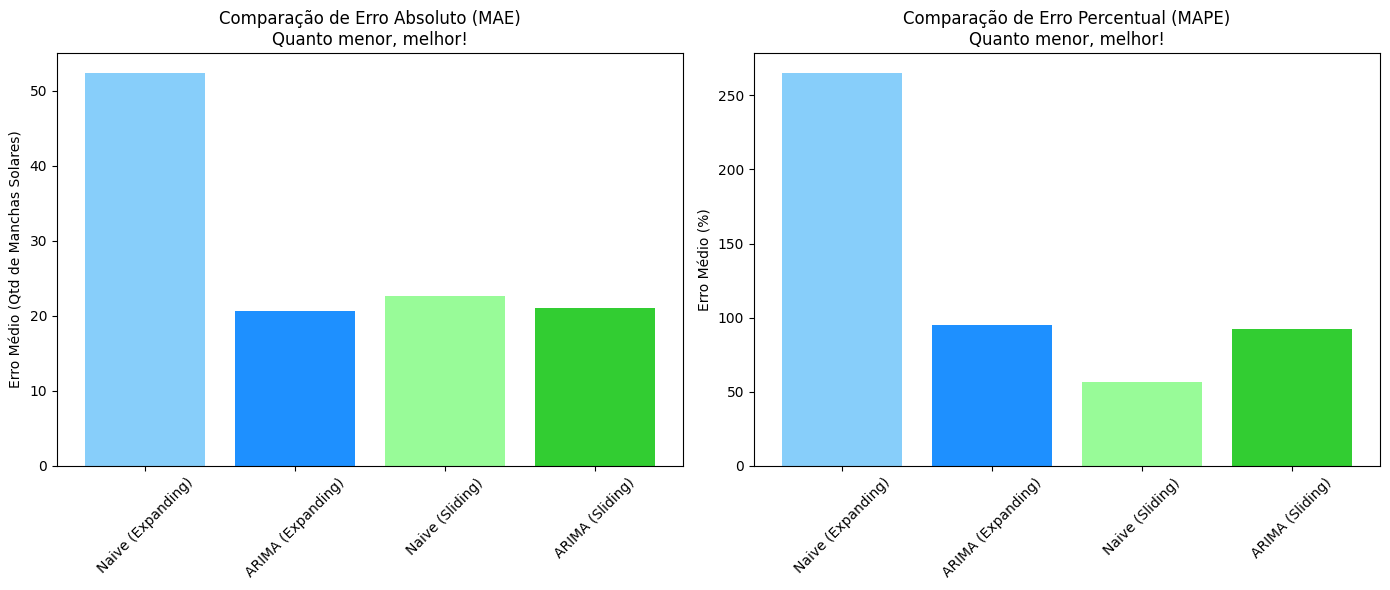

In [29]:
fig, eixos = plt.subplots(1, 2, figsize=(14, 6))

# Cores para cada barra (Azul claro/escuro para Expanding, Verde claro/escuro para Sliding)
cores = ['#87CEFA', '#1E90FF', '#98FB98', '#32CD32']

# GRÁFICO 1: Comparando o Erro Absoluto (MAE)
eixos[0].bar(tabela_resumo["Modelo e Estratégia"], tabela_resumo["MAE Médio (Manchas)"], color=cores)
eixos[0].set_title("Comparação de Erro Absoluto (MAE)\nQuanto menor, melhor!", fontsize=12)
eixos[0].set_ylabel("Erro Médio (Qtd de Manchas Solares)")
eixos[0].tick_params(axis='x', rotation=45) # Rotaciona os nomes para caberem bem

# GRÁFICO 2: Comparando o Erro Percentual (MAPE)
eixos[1].bar(tabela_resumo["Modelo e Estratégia"], tabela_resumo["MAPE Médio (%)"], color=cores)
eixos[1].set_title("Comparação de Erro Percentual (MAPE)\nQuanto menor, melhor!", fontsize=12)
eixos[1].set_ylabel("Erro Médio (%)")
eixos[1].tick_params(axis='x', rotation=45)

# Ajusta o layout para não ficar nada cortado ou apertado
plt.tight_layout()

# Mostra o gráfico na tela!
plt.show()

**Compreensão dos Resultados**

Temos dois avaliadores diferentes (MAE e MAPE) avaliando dois modelos (Naive e ARIMA) em dois cenários (Expanding e Sliding). Vamos entender quem se saiu melhor e por quê.

**Avaliação Detalhada das Métricas**

*1. Avaliação pelo Erro Absoluto (MAE - Mean Absolute Error)*
O MAE diz para nós: "Em média, por quantas manchas solares o nosso modelo errou a previsão?"

O Grande Vencedor: ARIMA (Expanding), com 20.64 manchas de erro.

O Pior Desempenho: Naive (Expanding), que errou por quase 52 manchas.

O que aprendemos aqui? O modelo ARIMA conseguiu entender muito melhor as regras matemáticas por trás das manchas solares. Ele conseguiu manter um erro na casa de 20 a 21 manchas, independentemente de estarmos usando a janela Expanding (que olha toda a história) ou a Sliding (que olha apenas o passado recente).

*2. Avaliação pelo Erro Percentual (MAPE - Mean Absolute Percentage Error)*

O MAPE diz: "Proporcionalmente ao número real de manchas, qual foi a porcentagem de erro?"
O Vencedor **Inesperado**: Naive (Sliding), com 56.49% de erro.

O que aprendemos aqui? Temos uma "pegadinha" matemática muito comum em séries temporais! O modelo Naive com a janela Sliding conseguiu um erro percentual menor. Mas por que o ARIMA teve cerca de 92% a 95% de erro?

Explicação Didática: O ciclo solar tem "vales" onde o número de manchas cai para quase zero (ex: 2 ou 3 manchas num ano). Se o ARIMA prever 10 manchas, ele errou o número absoluto por muito pouco (apenas 7 manchas a mais), mas em porcentagem, ele errou por mais de 300%! Como o MAPE é muito sensível a números próximos de zero, ele "puniu" o ARIMA duramente.

*3. Estabilidade e Robustez do Modelo*

O verdadeiro teste de um modelo de Inteligência Artificial é a sua estabilidade.

Repare no ARIMA: Os números dele mal mudaram entre a estratégia Expanding e a Sliding (MAE foi de 20.6 para 21.0, e MAPE de 95% para 92%). Ele é um modelo sólido e confiável.

Repare no Naive: Ele foi um desastre na estratégia Expanding (um erro absurdo de 265% e 52 manchas) e depois melhorou na Sliding. Ele é um modelo altamente instável.

In [30]:
# Exemplo: horizontes de 1 a 12 meses
fh_12 = ForecastingHorizon(
    np.arange(1, 13),
    is_relative=True
)

print(fh_12)

ForecastingHorizon([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], dtype='int32', is_relative=True)


# 12. Como interpretar o resultado do backtesting?

Suponha que obtivemos:

| Modelo | MAE | RMSE | MAPE | MASE |
|---|---:|---:|---:|---:|
| Seasonal Naive | 20 | 30 | 8% | 1.00 |
| SARIMA | 15 | 23 | 6% | 0.75 |

Uma interpretação razoável seria:

- SARIMA apresentou menor erro absoluto;
- SARIMA apresentou menor penalização de grandes erros;
- SARIMA apresentou menor erro percentual;
- MASE = 0,75 indica erro aproximadamente 25% menor que a escala de referência.

Mas isso **não significa automaticamente que SARIMA é sempre melhor**.

Devemos observar:

1. desempenho em todos os folds;
2. estabilidade;
3. desempenho por horizonte;
4. período em que cada erro ocorreu;
5. complexidade do modelo;
6. objetivo de negócio.

### Regra importante

> **O melhor modelo é aquele que apresenta desempenho preditivo consistente no cenário de validação escolhido, e não necessariamente aquele que possui o menor erro em um único período.**

# 13. Desenvolvimento × Teste final

Uma avaliação profissional deve separar:

```text
DADOS
  │
  ├────────────── DESENVOLVIMENTO ──────────────┐
  │                                             │
  │                                      BACKTESTING
  │                                             │
  │                               escolha do modelo
  │                                             │
  └─────────────────────── TESTE FINAL ─────────┘
```

O teste final deve ficar **intocado** durante:

- seleção do modelo;
- seleção de hiperparâmetros;
- escolha do tamanho da janela;
- escolha do benchmark;
- escolha das transformações.

Depois de escolher o modelo:

1. reajustamos no conjunto de desenvolvimento;
2. fazemos previsão no teste final;
3. calculamos as métricas;
4. reportamos o resultado final.

Isso evita uma avaliação otimista.

# 14. Expanding Window × Sliding Window

## Expanding

Use quando:

- o histórico completo continua relevante;
- mais dados ajudam a estimar os parâmetros;
- não há forte evidência de mudança de regime.

## Sliding / Rolling

Use quando:

- há mudança estrutural;
- o comportamento recente é mais representativo;
- dados muito antigos podem prejudicar o modelo.

Não existe uma estratégia universalmente melhor.

A escolha deve ser baseada no **processo gerador dos dados** e no cenário operacional.

# 15. Benchmark é obrigatório

Para cada problema devemos estabelecer pelo menos uma referência simples.

### Série não sazonal

```python
NaiveForecaster(strategy="last")
```

### Série sazonal

```python
NaiveForecaster(
    strategy="last",
    sp=12
)
```

Se um ARIMA/SARIMA sofisticado não supera o benchmark, precisamos questionar:

- a ordem do modelo;
- o horizonte;
- a estratégia de atualização;
- a existência de informação preditiva adicional;
- a própria necessidade do modelo.

> **Complexidade não é sinônimo de melhor previsão.**

# 16. Comparação conceitual das bibliotecas

| Necessidade | `scikit-learn` | `sktime` | `statsmodels` |
|---|---|---|---|
| ML geral | Excelente | Bom | Não é o foco |
| `TimeSeriesSplit` | ✅ | — | — |
| Holdout temporal | possível | ✅ | possível |
| Expanding Window | limitado | ✅ | — |
| Sliding Window | limitado | ✅ | — |
| Forecasting Horizon | limitado | ✅ | — |
| Backtesting integrado | limitado | ✅ | parcial |
| Métricas de forecasting | limitado | ✅ | várias |
| ARIMA | — | ✅ | ✅ |
| SARIMA | — | ✅ | ✅ |

### Conclusão

Para uma disciplina de séries temporais, `sktime` oferece uma abstração muito próxima do problema que queremos ensinar:

**série → janela temporal → horizonte → forecaster → previsão → métrica → backtesting**.

# 17. Fluxo recomendado para projetos reais

```text
                 SÉRIE TEMPORAL
                       │
                       ▼
             Ordenação temporal
                       │
                       ▼
            TESTE FINAL SEPARADO
                       │
                       ▼
             DESENVOLVIMENTO
                       │
                       ▼
          ┌─────────────────────┐
          │ Temporal CV /       │
          │ Backtesting         │
          └──────────┬──────────┘
                     │
          ┌──────────┴──────────┐
          ▼                     ▼
    Expanding Window      Sliding Window
          │                     │
          └──────────┬──────────┘
                     ▼
              Benchmark
                     │
                     ▼
              ARIMA/SARIMA
                     │
                     ▼
                 MÉTRICAS
                     │
        ┌────┬────┬──┴──┬────┬────┬────┐
        ▼    ▼    ▼     ▼    ▼    ▼
       MAE  MSE RMSE   MAPE sMAPE MASE
                     │
                     ▼
             Escolha do modelo
                     │
                     ▼
             Reajuste final
                     │
                     ▼
              TESTE FINAL
```

A grande mudança de paradigma é:

> **Cross-validation em séries temporais não consiste em embaralhar os dados. Consiste em reproduzir várias situações históricas de previsão.**